# COSI Pulsar Analysis Tutorial: Phase Assignment and Filtering

## Overview
This tutorial demonstrates a complete workflow for performing phase-resolved pulsar analysis using `cosipy` and custom time-domain tools. Using Data Challenge 2 (DC2) FITS data for the Crab pulsar and its accompanying albedo background, this notebook guides you through the process of preparing unbinned photon events, assigning rotational phases, and extracting specific pulse intervals.

## Objectives
By the end of this notebook, you will learn how to:
* **Combine and Time-Slice Data:** Merge unbinned source and background datasets, and filter them down to specific Mission Elapsed Time (MET) windows for faster processing.
* **Assign Pulsar Phases:** Use a pulsar ephemeris parameter file (`.par`) to calculate and append the precise rotational phase (0.0 to 1.0) to individual photon events.
* **Visualize the Pulse Profile:** Generate a folded light curve (pulse profile) to visually inspect the on-pulse peaks and off-pulse baseline.
* **Perform Phase Selection:** Filter the phase-assigned data to isolate specific windows, such as the `on-pulse` and `off-pulse` regions, outputting the results into new FITS files for downstream spatial or spectral analysis.

## Prerequisites
To run this notebook, ensure you have the following in your working directory:
* A valid ephemeris file (e.g., `crab.par`)


In [1]:
import astropy.units as u
from astropy.time import Time
from cosipy import BinnedData
from cosipy.data_io import UnBinnedData
from astropy.io import fits
from cosipy.util import fetch_wasabi_file

from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.phase_resolved_analysis.ephemeris import PulsarTimingModel
from cosipy.phase_resolved_analysis.phase_assigner import PhaseAssigner
from cosipy.phase_resolved_analysis.phase_selector import PhaseSelector
from cosipy.phase_resolved_analysis.plot_pulse_profile import PlotPulseProfile


%matplotlib inline

Welcome to JupyROOT 6.28/12


14:28:06 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=881912;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=574433;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=773511;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=57367;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

14:28:07 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=981755;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=717335;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

14:28:07 INFO      Starting 3ML!                                                                     ]8;id=505001;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=55903;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=192361;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=811761;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

14:28:08 WARNING   No fermitools installed                                              ]8;id=958329;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=636911;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=887527;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=316555;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=909118;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=756953;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=622907;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=248900;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
fetch_wasabi_file('COSI-SMEX/DC2/Data/Sources/Crab_DC2_3months_unbinned_data.fits.gz', output=str('Crab_DC2_3months_unbinned_data.fits.gz'), unzip=True, checksum="539e432bc9843d20396dd6a210772b6e")


A file named Crab_DC2_3months_unbinned_data.fits already exists with the specified checksum (539e432bc9843d20396dd6a210772b6e). Skipping.


In [3]:
fetch_wasabi_file('COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori', output=str('20280301_3_month_with_orbital_info.ori'), checksum = '416fcc296fc37a056a069378a2d30cb2')

A file named 20280301_3_month_with_orbital_info.ori already exists with the specified checksum (416fcc296fc37a056a069378a2d30cb2). Skipping.


In [4]:
fetch_wasabi_file('COSI-SMEX/DC2/Data/Backgrounds/albedo_photons_3months_unbinned_data.fits.gz', output=str("albedo_photons_3months_unbinned_data.fits.gz"), unzip=True, checksum = '7a53f74d025a134adc2a8de73f1fe2cf')

A file named albedo_photons_3months_unbinned_data.fits already exists with the specified checksum (7a53f74d025a134adc2a8de73f1fe2cf). Skipping.


In [5]:
# This code can be removed once COSI Data-IO has support for slicing unbinned data by time. 

met_start = 1835478000.0
met_stop = met_start + 10*86400.0

for f_in, f_out in [("Crab_DC2_3months_unbinned_data.fits", "crab_10d.fits"), 
                    ("albedo_photons_3months_unbinned_data.fits", "albedo_10d.fits")]:
    with fits.open(f_in) as hdul:
        data = hdul[1].data
        mask = (data['TimeTags'] >= met_start) & (data['TimeTags'] <= met_stop)
        
        new_hdu = fits.BinTableHDU(data[mask], header=hdul[1].header)
        fits.HDUList([hdul[0], new_hdu]).writeto(f_out, overwrite=True)
    print(f"Slice created: {f_out} ({mask.sum()} events)")


Slice created: crab_10d.fits (831909 events)
Slice created: albedo_10d.fits (5241280 events)


In [6]:
analysis = BinnedData("inputs.yaml")
analysis.combine_unbinned_data(["crab_10d.fits", "albedo_10d.fits"], output_name="crab_with_albedo_10d")

In [7]:
# --- INITIALIZE TIMING MODEL ---
# Define the reference epoch (T0)
t0 = Time(59000.0, format='mjd', scale='tdb')

# Initialize the simple constant-frequency model
timing_model = PulsarTimingModel.from_par_file('crab.par', t0)
print(f"Loaded Pulsar Spin Frequency: {timing_model.f0:.6f}")

Loaded Pulsar Spin Frequency: 29.946923 Hz


In [8]:
# --- ASSIGN PHASES TO DATA ---
input_fits_file = "crab_with_albedo_10d.fits.gz"
output_fits_file = "crab_with_albedo_10d_with_pulse_phase.fits"

# Pass the protocol object directly!
assigner = PhaseAssigner(timing_model)
assigner.add_phase_column(input_fits_file, output_fits_file)

print(f"Done! Created: {output_fits_file}")

Done! Created: crab_with_albedo_10d_with_pulse_phase.fits


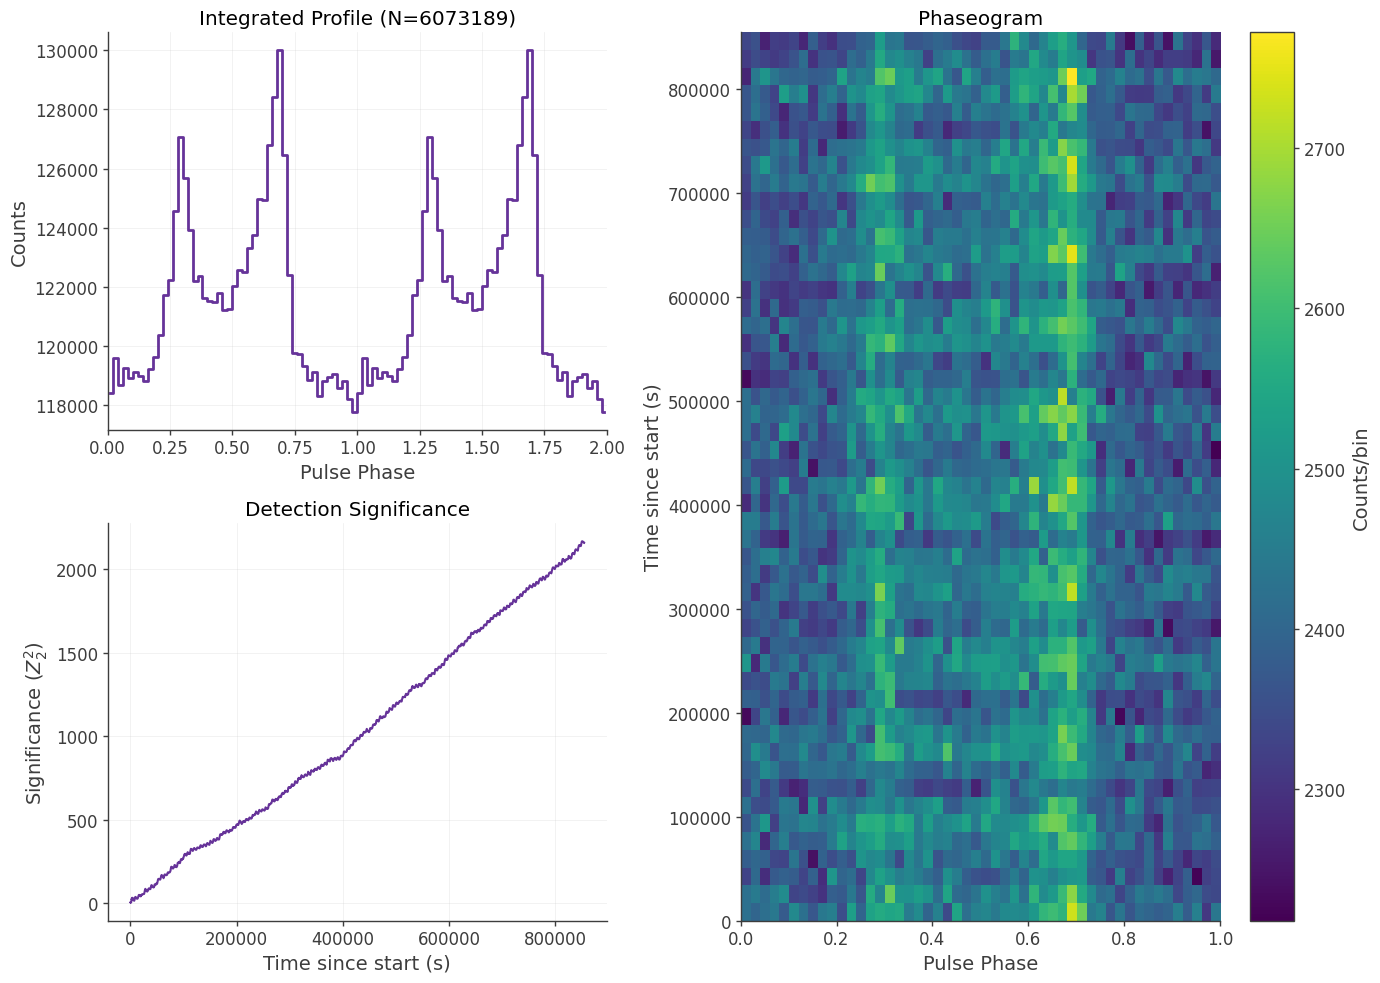

In [9]:
filename = "crab_with_albedo_10d_with_pulse_phase.fits"
with fits.open(filename) as hdul:
    pp = PlotPulseProfile(hdul[1].data)
    pp.plot()

The PhaseSelector is designed to isolate specific "windows" of a pulsar's rotation (e.g., the Main Pulse or the Interpulse). Unlike basic selectors that only allow one range, this class accepts a list of tuples. This allows you to select multiple distinct regions of the pulse profile in a single execution.

In [10]:
# input_fits = "crab_with_albedo_with_pulse_phase_column.fits"
# output_fits = "crab_with_albedo_with_pulse_phase_column_onpulse.fits"

input_fits = "crab_with_albedo_10d_with_pulse_phase.fits"
output_fits = "crab_with_albedo_10d_with_pulse_phase_onpulse.fits"

# Each tuple represents (pstart, pstop).
# Values must be between 0.0 and 1.0.
intervals = [
    (0.25, 0.40),  
    (0.55, 0.75),  
]

# Initialize the selector with your list of intervals
phase_sel = PhaseSelector(intervals=intervals)

# Run the filter. This returns a structured NumPy array for immediate analysis
# and writes the filtered data to a new FITS file.
on_pulse_events = phase_sel.filter_events(
    input_fits, 
    output_fits=output_fits
)

In [11]:
# --- CORRECT MISSION EXPOSURE ---

# 1. Load the original spacecraft pointing history
ori_file = '20280301_3_month_with_orbital_info.ori'
print(f"Loading SpacecraftHistory from {ori_file}...")
sc_history = SpacecraftHistory.open(ori_file)

# Let's look at the first few bins of the original livetime
print("\n--- BEFORE CORRECTION ---")
print(f"Original Livetime Array (first 5 bins): \n{sc_history._livetime_hist.contents[:5]}")

# Define the phase cut
intervals = [
    (0.25, 0.40),  
    (0.55, 0.75),  
]

expected_fraction = sum([stop - start for start, stop in intervals])
print(f"\nPhase Cut Total Width: {expected_fraction * 100:.0f}%")

# 2. Apply the correction using the protocol
print("Applying phase exposure correction...")
sc_history.update_ephemeris(timing_model, intervals)

print("\n--- AFTER CORRECTION ---")
print(f"Corrected Livetime Array (first 5 bins): \n{sc_history._livetime_hist.contents[:5]}")
print(f"\nExposure is now perfectly scaled to {expected_fraction * 100:.0f}%!")

Loading SpacecraftHistory from 20280301_3_month_with_orbital_info.ori...

--- BEFORE CORRECTION ---
Original Livetime Array (first 5 bins): 
[1. 1. 1. 1. 1.] s

Phase Cut Total Width: 35%
Applying phase exposure correction...

--- AFTER CORRECTION ---
Corrected Livetime Array (first 5 bins): 
[0.35 0.35 0.35 0.35 0.35] s

Exposure is now perfectly scaled to 35%!


## Conclusion

In this tutorial, we successfully processed raw, unbinned COSI data to assign rotational phases and extract specific phase intervals for the Crab pulsar and its corresponding albedo background. 

By isolating the `on-pulse` and `off-pulse` regions into separate FITS files, the data is now fully prepared for downstream analysis. Specifically, these newly created files can be plugged directly into `cosipy` to perform a **Spectral Fit** for the Crab pulsar. This will allow you to characterize its emission spectrum and analyze the background-subtracted source components.